# IoT Intrusion Detection — Capstone Project
This notebook merges the three project stages into a single pipeline: data preprocessing, exploratory data analysis, and modeling for classifying IoT network traffic as normal or attack.

## Important imports

In [53]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score ,roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression ,RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Data Preprocessing

## Load and clean the raw dataset

In [54]:
df = pd.read_csv('final_dataset.csv')
df = df.drop_duplicates()
df = df.drop(columns=['Idle Mean', 'Idle Max'])

iat_cols = ['Flow IAT Min', 'Fwd IAT Min']
mask = (df[iat_cols] < 0).any(axis=1)
print(f"Dropping {mask.sum()} rows with invalid negative IAT values")
df = df[~mask]

Dropping 3 rows with invalid negative IAT values


## Save the cleaned dataset (with collinear features still present)

In [55]:
df.to_csv('IoT_Intrusion_Detection_w_colinearity.csv', index=False)

## Statistical summary

In [56]:
pd.set_option('display.max_columns', None)
df.describe(include='all')

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Fwd Packet Length Min,Bwd Packet Length Max,Flow IAT Min,Fwd IAT Min,Fwd Header Length,Bwd Packets/s,Packet Length Max,Packet Length Std,RST Flag Count,FWD Init Win Bytes,Bwd Init Win Bytes,FIN Flag Count,SYN Flag Count,ACK Flag Count,Label
count,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06,1.175217e+06
mean,3.670145e+04,1.571196e+04,6.387389e+00,5.315603e+06,5.489453e+00,5.489510e+00,5.155638e+03,1.155945e+01,1.531754e+02,2.267170e+06,2.823916e+06,1.456671e+02,4.281063e+03,2.136598e+02,5.329318e+01,4.925414e-01,6.144965e+03,5.663323e+02,8.521745e-02,6.305687e-01,8.865505e+00,7.370137e-01
std,2.369892e+04,2.062438e+04,4.959338e+00,1.188459e+07,1.754780e+02,2.129512e+02,4.643030e+05,4.839406e+01,1.027185e+03,5.939618e+06,6.720616e+06,8.480036e+03,3.864946e+04,1.286025e+03,2.838734e+02,5.309197e-01,1.714930e+04,4.512233e+03,2.983377e-01,7.130236e-01,3.761666e+02,4.402552e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.900000e+03,5.300000e+01,6.000000e+00,3.371000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.750000e+03,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.980100e+04,3.128000e+03,6.000000e+00,6.794000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.545000e+03,0.000000e+00,2.400000e+01,1.343183e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.024000e+03,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,5.529500e+04,3.200800e+04,6.000000e+00,3.121955e+06,2.000000e+00,1.000000e+00,2.400000e+01,2.000000e+00,0.000000e+00,9.022700e+04,9.218910e+05,2.400000e+01,2.866972e+02,2.400000e+01,1.154701e+00,1.000000e+00,1.024000e+03,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,6.553500e+04,6.553500e+04,1.700000e+01,6.094632e+07,7.418000e+04,7.247000e+04,2.382375e+08,1.553300e+04,6.486000e+04,6.021332e+07,6.021332e+07,4.294840e+06,2.000000e+06,6.486000e+04,8.504488e+03,1.000000e+01,6.553500e+04,6.553500e+04,2.000000e+00,1.600000e+01,1.466490e+05,1.000000e+00


## Feature type and missing value overview

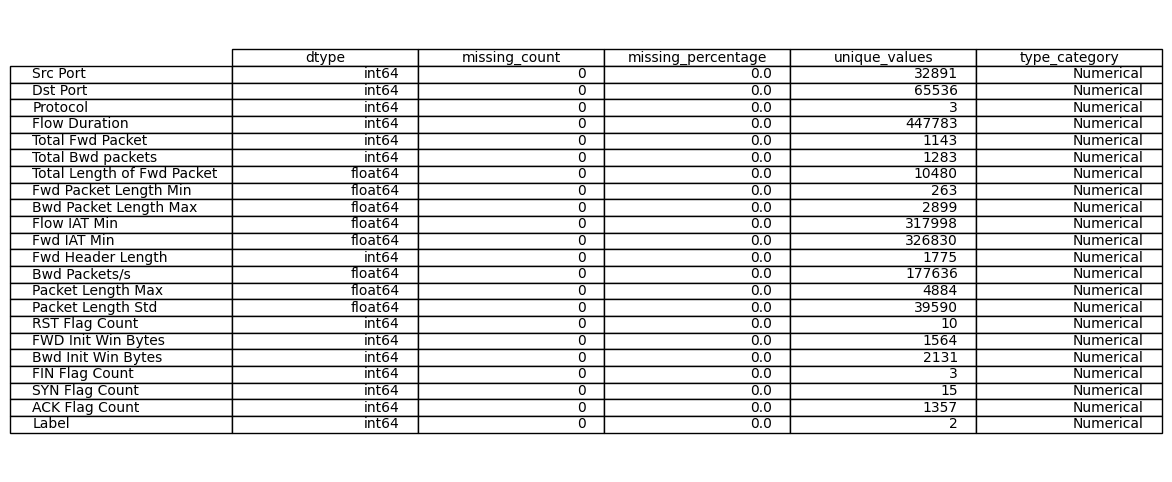

In [57]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_percentage': (df.isna().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique(),
    'type_category': ['Numerical' if dt in ['int64', 'float64'] else 'Categorical' for dt in df.dtypes]
})

fig, ax = plt.subplots(figsize=(12, 6))
ax.xaxis.visible = False
ax.yaxis.visible = False
ax.axis('off')
pd.plotting.table(ax, summary, loc='center', colWidths=[0.2]*len(df.columns))
plt.show()

## Feature correlation before removing collinear features

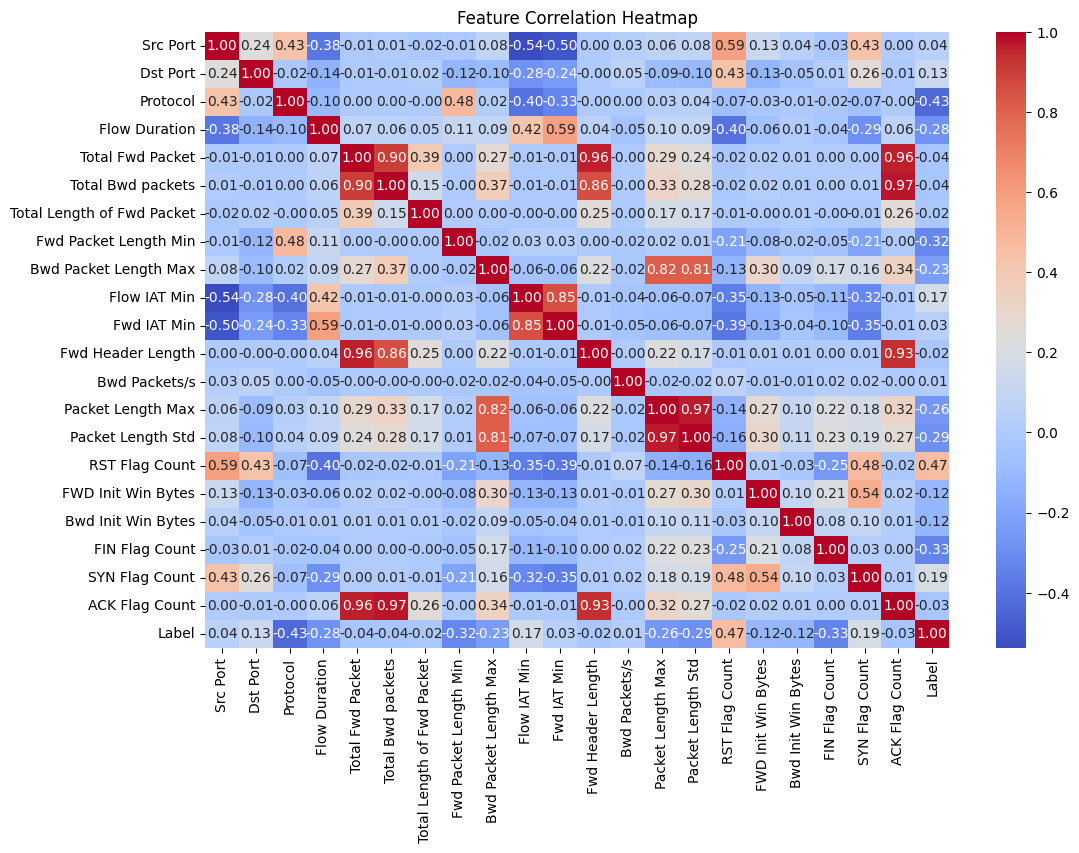

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True , cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### The heatmap reveals several near-duplicate features
Very strong correlations appear between Total Fwd Packet / Fwd Header Length / ACK Flag Count (~0.96), Total Bwd packets / ACK Flag Count (~0.97), Packet Length Max / Packet Length Std (~0.97), and Flow IAT Min / Fwd IAT Min (~0.85). These pairs carry largely the same information, so keeping all of them would introduce redundant, collinear features into the models.

## Remove highly collinear features and save the final dataset

In [59]:
df = df.drop(columns=['Packet Length Max' , 'ACK Flag Count' , 'Total Bwd packets' , 'Fwd Header Length', 'Fwd IAT Min','Bwd Packet Length Max'])
df.to_csv('IoT_Intrusion_Detection_no_colinearity.csv', index=False)

## Feature correlation after removing collinear features

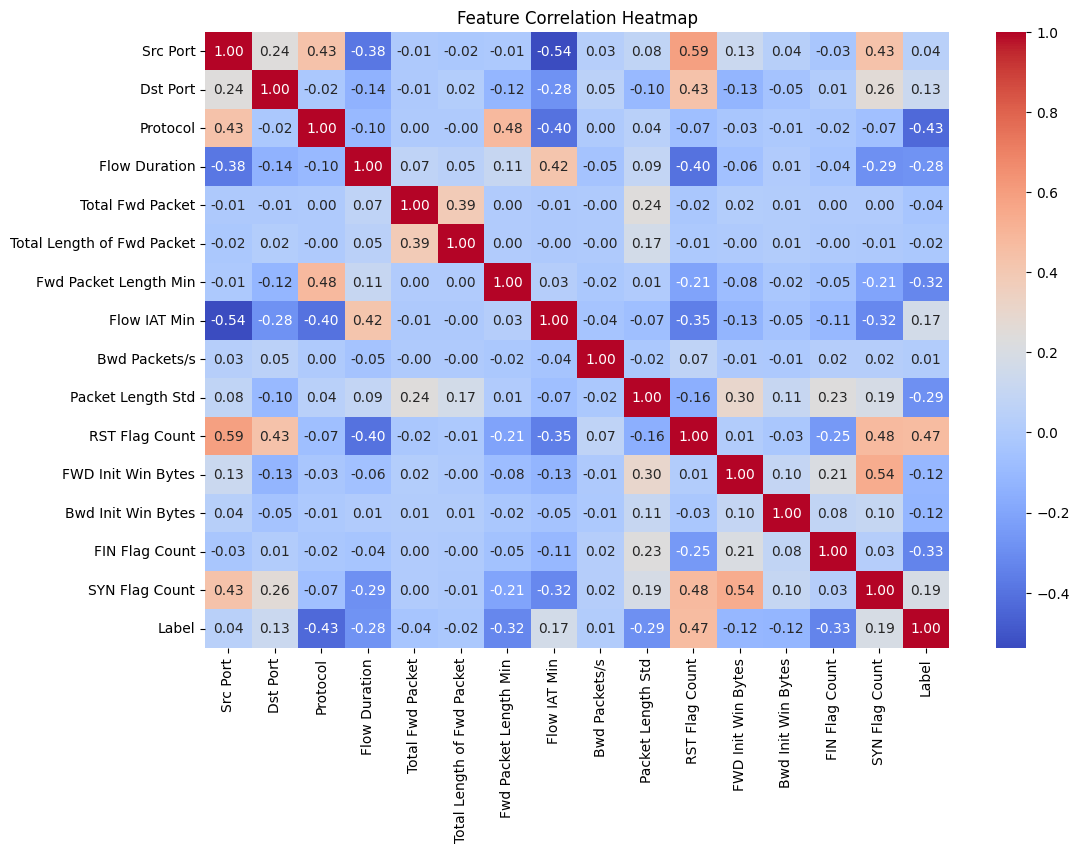

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True , cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Multicollinearity is resolved
After dropping the six redundant features, the strongest remaining pairwise correlation drops to about 0.59 (Src Port and RST Flag Count), with everything else well below that. The remaining feature set no longer carries near-duplicate information, which makes it safer to feed into linear models.

# Exploratory Data Analysis

## Load the dataset and understand its structure

In [61]:
# LOAD DATASET

DATA_PATH = "IoT_Intrusion_Detection_w_colinearity.csv"

df = pd.read_csv(DATA_PATH)

In [62]:
print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1175217, 22)


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Fwd Packet Length Min,Bwd Packet Length Max,Flow IAT Min,Fwd IAT Min,Fwd Header Length,Bwd Packets/s,Packet Length Max,Packet Length Std,RST Flag Count,FWD Init Win Bytes,Bwd Init Win Bytes,FIN Flag Count,SYN Flag Count,ACK Flag Count,Label
0,33344,443,6,379933,11,11,720.0,0.0,2736.0,1.0,1.0,360,28.952473,2736.0,669.529745,0,29200,131,1,2,21,0
1,36754,80,6,205637,3,3,87.0,0.0,189.0,0.0,0.0,104,14.588814,189.0,73.493440,0,29200,508,1,2,5,0
2,36754,80,6,0,2,0,0.0,0.0,0.0,0.0,0.0,64,0.000000,0.0,0.000000,0,237,0,1,0,2,0
3,8080,40426,6,5030379,1,2,6.0,6.0,0.0,0.0,0.0,20,0.397584,6.0,3.464102,0,2048,123,1,0,3,0
4,40054,80,6,72278,3,4,87.0,0.0,148.0,205.0,2458.0,104,55.341874,148.0,56.782637,0,29200,508,1,2,6,0


## Dataset information

In [63]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.value_counts())

print("\nDataset information:")
df.info()

Number of rows: 1175217
Number of columns: 22

Data types:


int64      14
float64     8
Name: count, dtype: int64


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1175217 entries, 0 to 1175216
Data columns (total 22 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Src Port                    1175217 non-null  int64  
 1   Dst Port                    1175217 non-null  int64  
 2   Protocol                    1175217 non-null  int64  
 3   Flow Duration               1175217 non-null  int64  
 4   Total Fwd Packet            1175217 non-null  int64  
 5   Total Bwd packets           1175217 non-null  int64  
 6   Total Length of Fwd Packet  1175217 non-null  float64
 7   Fwd Packet Length Min       1175217 non-null  float64
 8   Bwd Packet Length Max       1175217 non-null  float64
 9   Flow IAT Min                1175217 non-null  float64
 10  Fwd IAT Min                 1175217 non-null  float64
 11  Fwd Header Length           1175217 non-null  int64  
 12  Bwd Packets/s               1175217 non-null 

In [64]:
print("Missing values:")
missing = df.isnull().sum()

display(
    missing[missing > 0].sort_values(ascending=False)
)

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nInfinite values:")

numeric_cols = df.select_dtypes(include=np.number).columns

infinite_count = np.isinf(df[numeric_cols]).sum().sum()

print(infinite_count)

Missing values:


Series([], dtype: int64)


Total missing values: 0

Infinite values:
0


### After removing the Idle Mean and Idle Max features, 4,312 rows became identical across the remaining features. These rows were retained because the apparent duplication may result from the removal of those features rather than genuine duplicate observations

## Understand the target variable

In [65]:
label_counts = df["Label"].value_counts().sort_index()

print(label_counts)

print("\nPercentages:")
print(
    (df["Label"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

Label
0    309066
1    866151
Name: count, dtype: int64

Percentages:
Label
0    26.3
1    73.7
Name: proportion, dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_34040\2711684789.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Normal (0)", "Attack (1)"])


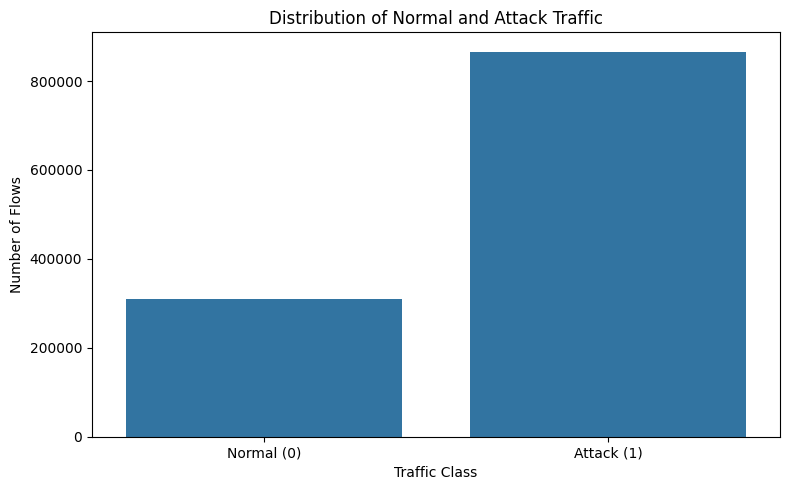

In [66]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Label"
)

plt.title("Distribution of Normal and Attack Traffic")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Flows")

ax.set_xticklabels(["Normal (0)", "Attack (1)"])

plt.tight_layout()
plt.show()

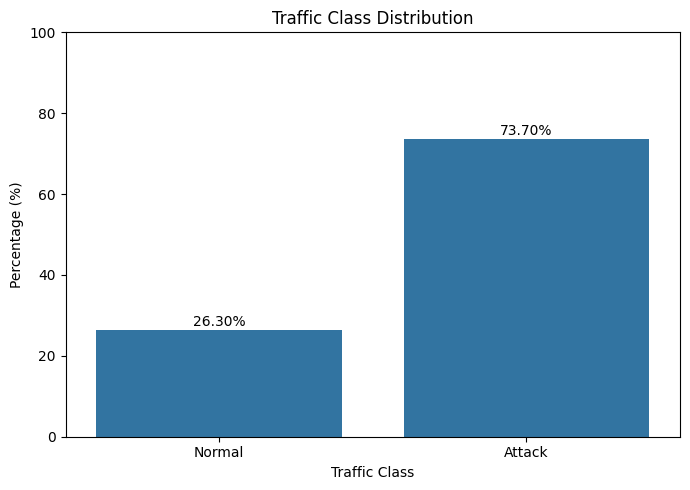

In [67]:
#with percentage

label_percent = (
    df["Label"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=["Normal", "Attack"],
    y=label_percent.values
)

plt.title("Traffic Class Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Percentage (%)")

for i, value in enumerate(label_percent.values):
    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Target distribution is approximately:
| Class  | Percentage |
| ------ | ---------: |
| Normal |     26.30% |
| Attack |     73.70% |

So the dataset is imbalanced toward attack traffic

## Understand the features

In [68]:
# FEATURE SUMMARY

feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Zero Values": (df == 0).sum(),
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Std": df.std(numeric_only=True),
    "Min": df.min(numeric_only=True),
    "Max": df.max(numeric_only=True)
})

display(feature_summary)

,Data Type,Unique Values,Missing Values,Zero Values,Mean,Median,Std,Min,Max
Src Port,int64,32891,0,236009,3.670145e+04,49801.000000,2.369892e+04,0.0,6.553500e+04
Dst Port,int64,65536,0,236138,1.571196e+04,3128.000000,2.062438e+04,0.0,6.553500e+04
Protocol,int64,3,0,236009,6.387389e+00,6.000000,4.959338e+00,0.0,1.700000e+01
Flow Duration,int64,447783,0,1916,5.315603e+06,6794.000000,1.188459e+07,0.0,6.094632e+07
Total Fwd Packet,int64,1143,0,0,5.489453e+00,1.000000,1.754780e+02,1.0,7.418000e+04
Total Bwd packets,int64,1283,0,334857,5.489510e+00,1.000000,2.129512e+02,0.0,7.247000e+04
Total Length of Fwd Packet,float64,10480,0,758395,5.155638e+03,0.000000,4.643030e+05,0.0,2.382375e+08
Fwd Packet Length Min,float64,263,0,868909,1.155945e+01,0.000000,4.839406e+01,0.0,1.553300e+04
Bwd Packet Length Max,float64,2899,0,947627,1.531754e+02,0.000000,1.027185e+03,0.0,6.486000e+04
Flow IAT Min,float64,317998,0,22298,2.267170e+06,4545.000000,5.939618e+06,0.0,6.021332e+07


### The dataset has severe skewness
Example -> Total Fwd Packet has approximately:

Median = 1 ,
   Maximum = 74,180
   


This tells us before modeling:

Some features will require transformation, particularly for scale-sensitive models.

In [69]:
#Identify highly skewed features
numeric_features = df.drop(columns="Label").select_dtypes(
    include=np.number
).columns

skewness = (
    df[numeric_features]
    .skew()
    .sort_values(key=lambda x: abs(x), ascending=False)
)

display(skewness.to_frame("Skewness"))

,Skewness
Fwd Header Length,294.415200
Total Length of Fwd Packet,261.666215
Total Fwd Packet,199.726027
ACK Flag Count,171.339378
Total Bwd packets,145.200378
Fwd Packet Length Min,36.781892
Bwd Packet Length Max,15.681354
Bwd Packets/s,14.793819
Bwd Init Win Bytes,12.277909
Packet Length Max,11.951574


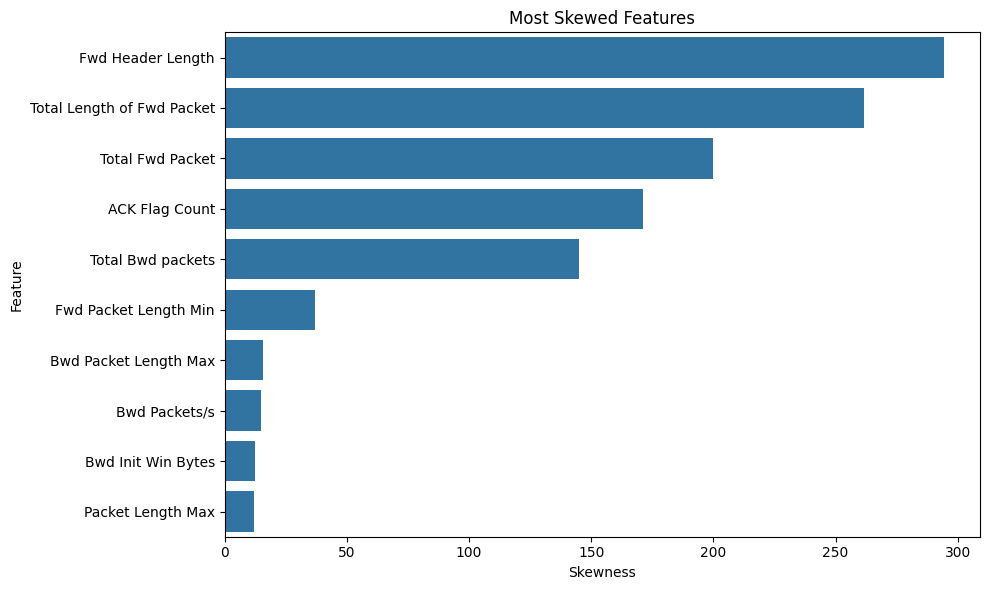

In [70]:
#visualize the worst ones
top_skewed = skewness.abs().sort_values(
    ascending=False
).head(10).index

plt.figure(figsize=(10, 6))

sns.barplot(
    x=skewness[top_skewed].values,
    y=top_skewed
)

plt.title("Most Skewed Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## KDE matrix

In [71]:
#Take a sample to make Kde
eda_sample = df.sample(
    n=min(50000, len(df)),
    random_state=42
)

print("EDA sample size:", len(eda_sample))

EDA sample size: 50000


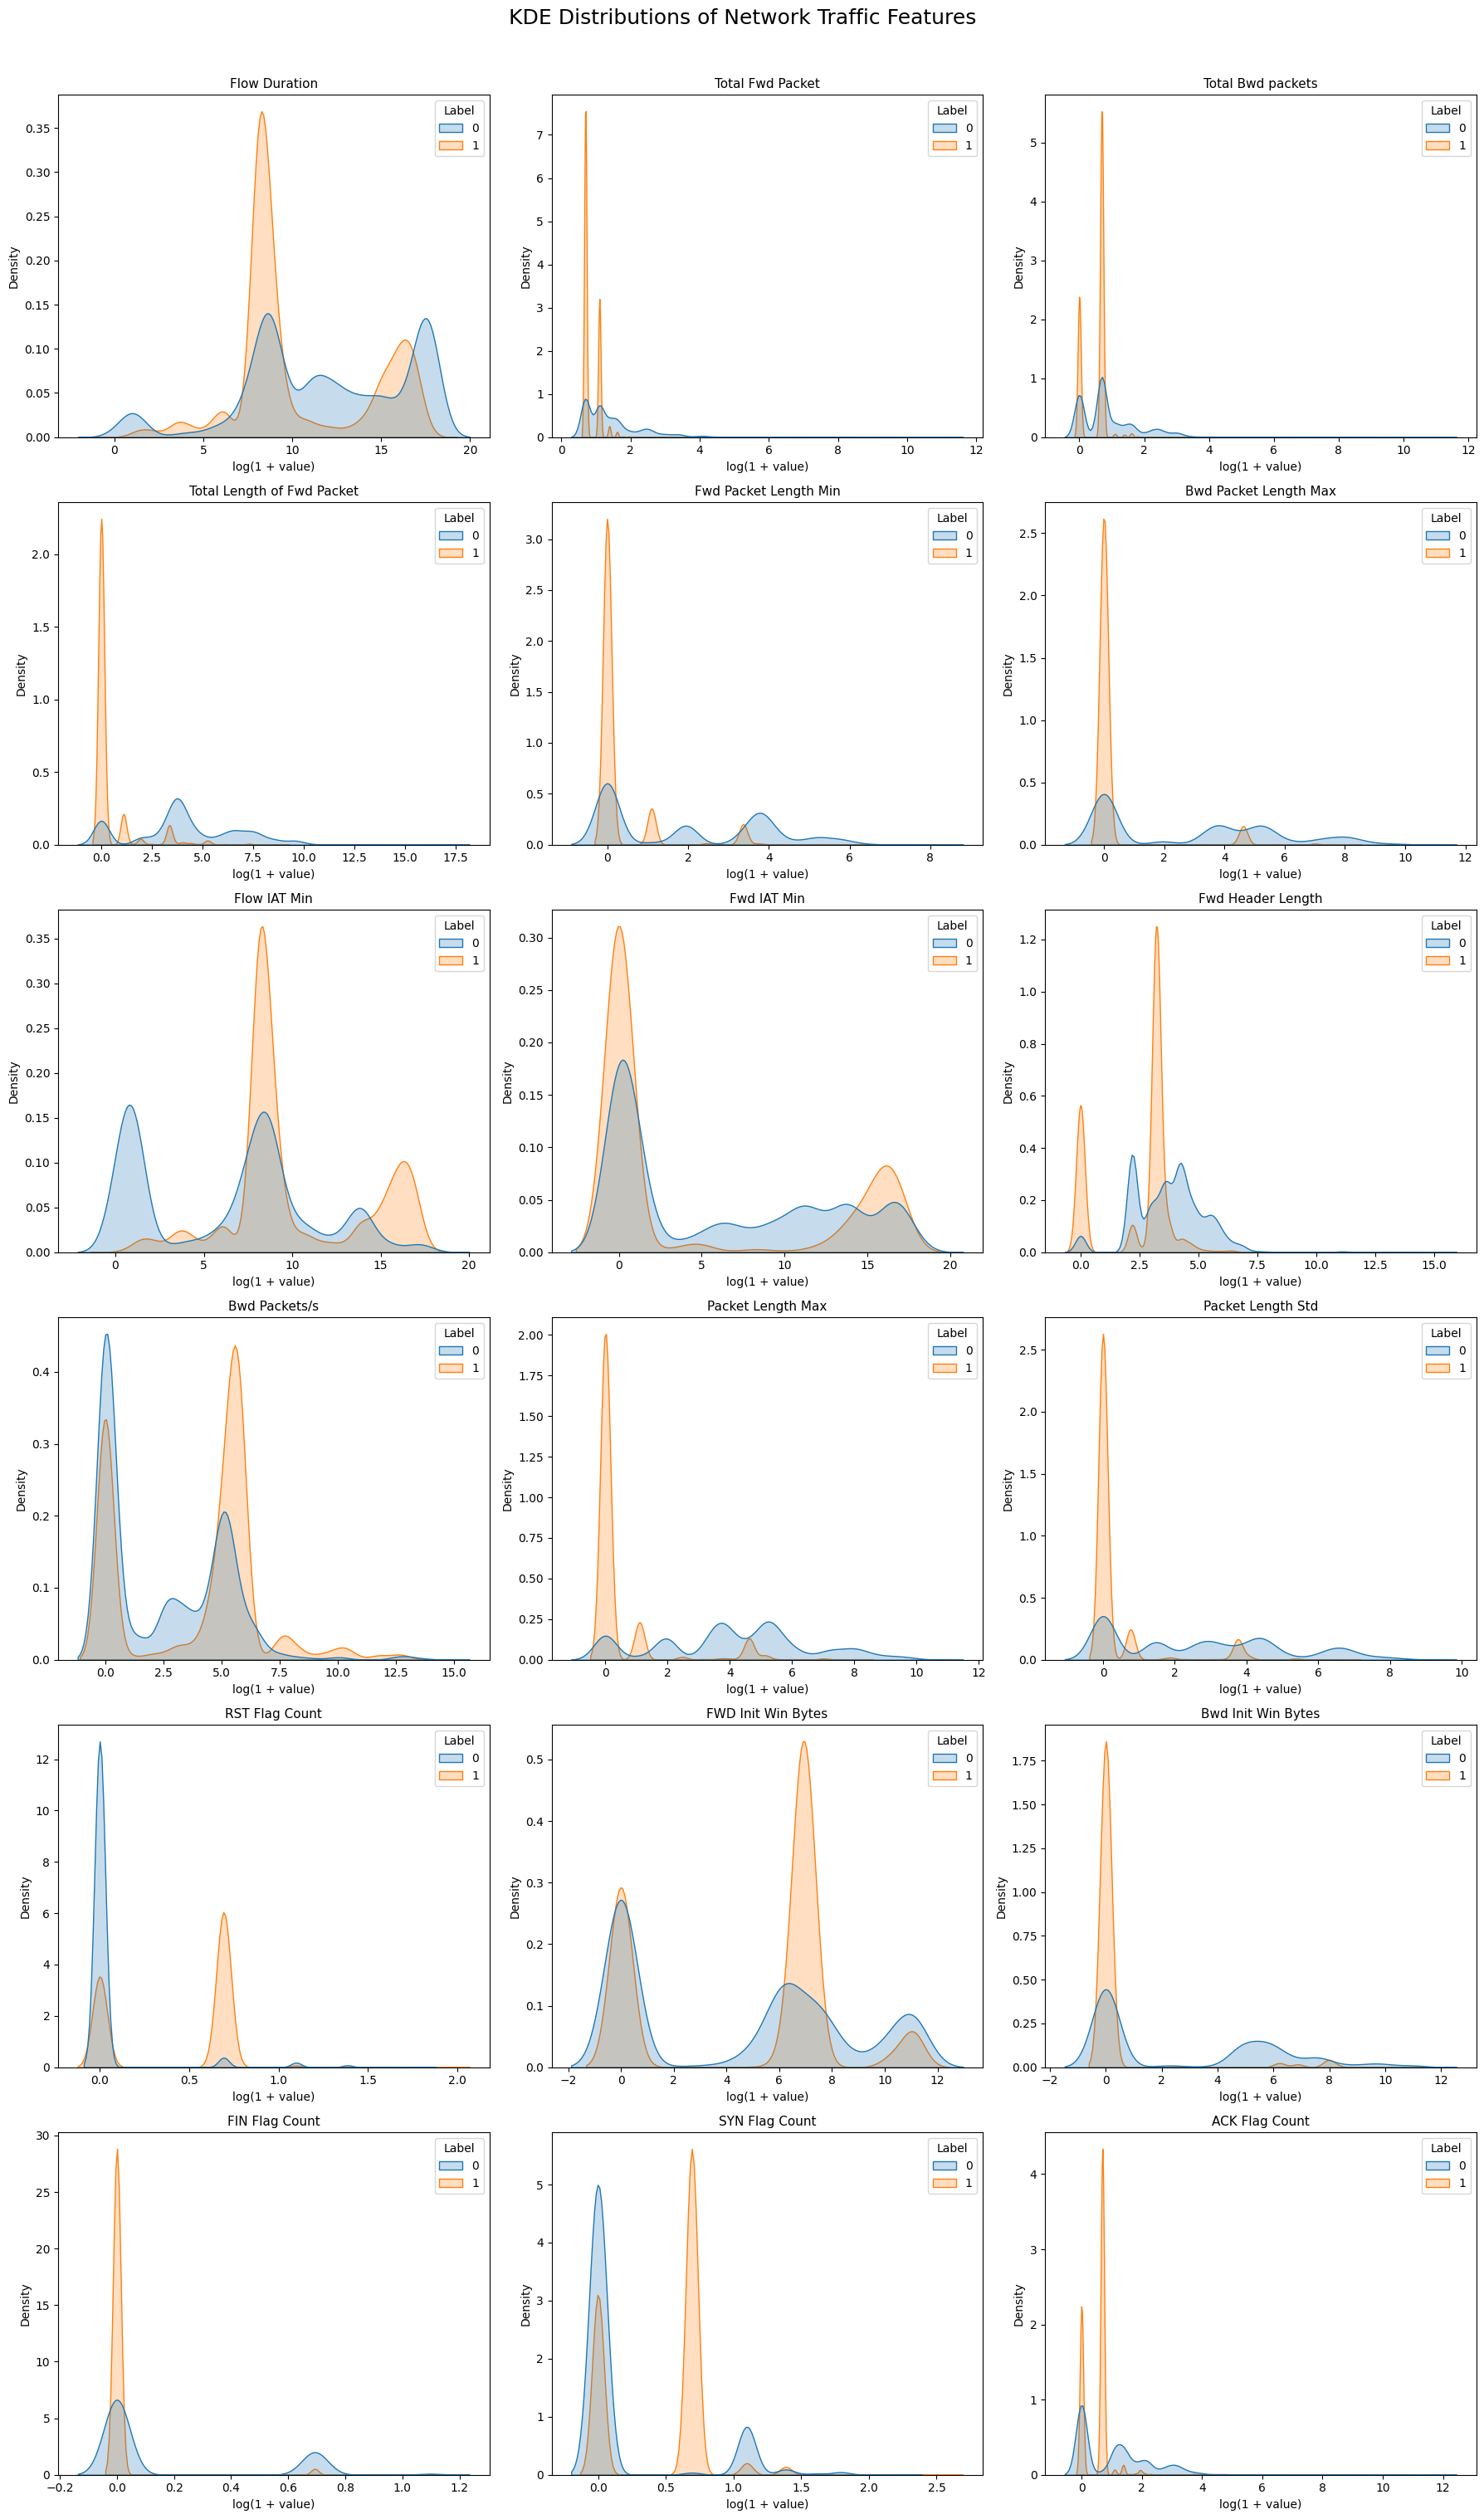

In [72]:
kde_features = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Fwd Packet Length Min",
    "Bwd Packet Length Max",
    "Flow IAT Min",
    "Fwd IAT Min",
    "Fwd Header Length",
    "Bwd Packets/s",
    "Packet Length Max",
    "Packet Length Std",
    "RST Flag Count",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "FIN Flag Count",
    "SYN Flag Count",
    "ACK Flag Count"
]

n_cols = 3
n_rows = int(np.ceil(len(kde_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for ax, feature in zip(axes, kde_features):

    temp = eda_sample[[feature, "Label"]].copy()

    # Compress highly skewed positive values
    temp[feature] = np.log1p(
        temp[feature].clip(lower=0)
    )

    sns.kdeplot(
        data=temp,
        x=feature,
        hue="Label",
        fill=True,
        common_norm=False,
        ax=ax
    )

    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("log(1 + value)")
    ax.set_ylabel("Density")

# Hide unused axes
for ax in axes[len(kde_features):]:
    ax.set_visible(False)

fig.suptitle(
    "KDE Distributions of Network Traffic Features",
    fontsize=18,
    y=1.01
)

plt.tight_layout()
plt.show()

###The KDE plots compare the distribution of each network-flow feature between normal and attack traffic. Log transformation was applied for visualization because several network features are highly right-skewed. Differences between the two distributions indicate that the feature may contain useful information for distinguishing attack traffic from normal traffic.

#Protocol analysis

###Does the type of network protocol differ between normal and attack traffic?

In [73]:
#  PROTOCOL DISTRIBUTION BY CLASS

protocol_table = pd.crosstab(
    df["Protocol"],
    df["Label"],
    normalize="index"
) * 100

protocol_table.columns = ["Normal", "Attack"]

display(protocol_table)

,Normal,Attack
Protocol,,
0,4.526522,95.473478
6,23.517985,76.482015
17,69.074183,30.925817


<Figure size 900x600 with 0 Axes>

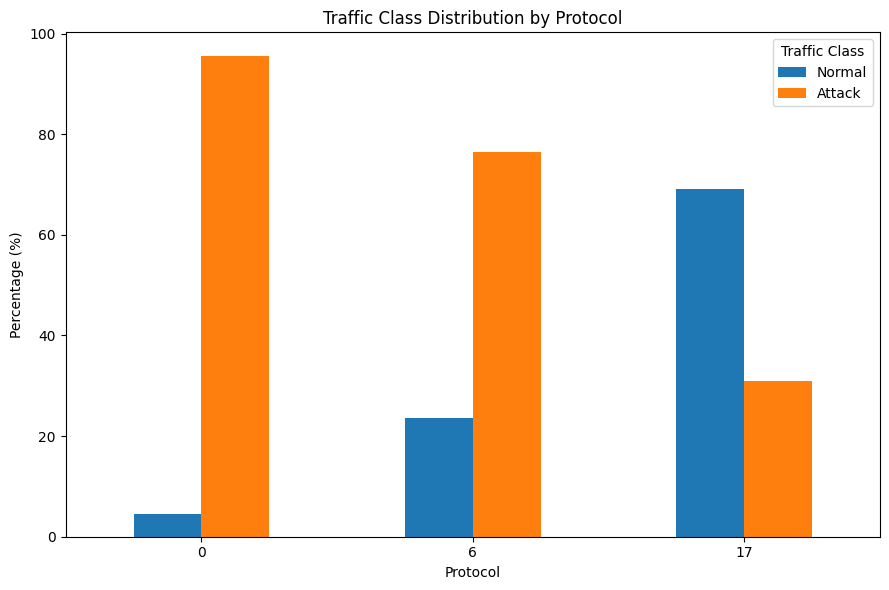

In [74]:
# Visualize
plt.figure(figsize=(9, 6))

protocol_plot = pd.crosstab(
    df["Protocol"],
    df["Label"],
    normalize="index"
) * 100

protocol_plot.columns = ["Normal", "Attack"]

protocol_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Traffic Class Distribution by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Traffic Class")

plt.tight_layout()
plt.show()

## Port analysis

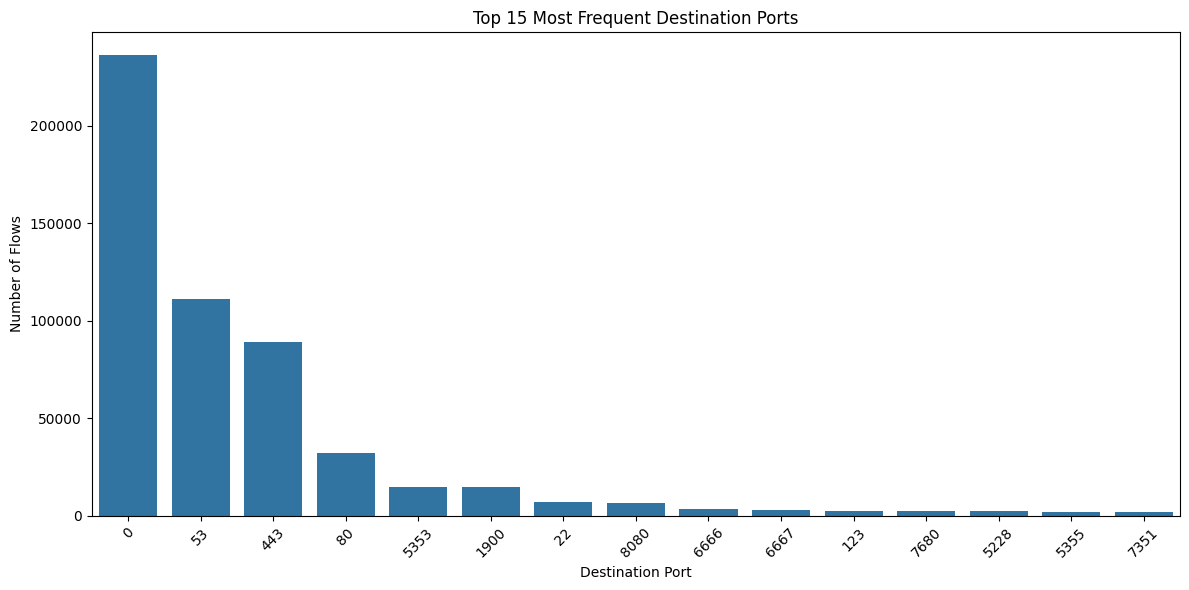

In [75]:
# TOP DESTINATION PORTS

top_dst_ports = (
    df["Dst Port"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_dst_ports.index.astype(str),
    y=top_dst_ports.values
)

plt.title("Top 15 Most Frequent Destination Ports")
plt.xlabel("Destination Port")
plt.ylabel("Number of Flows")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

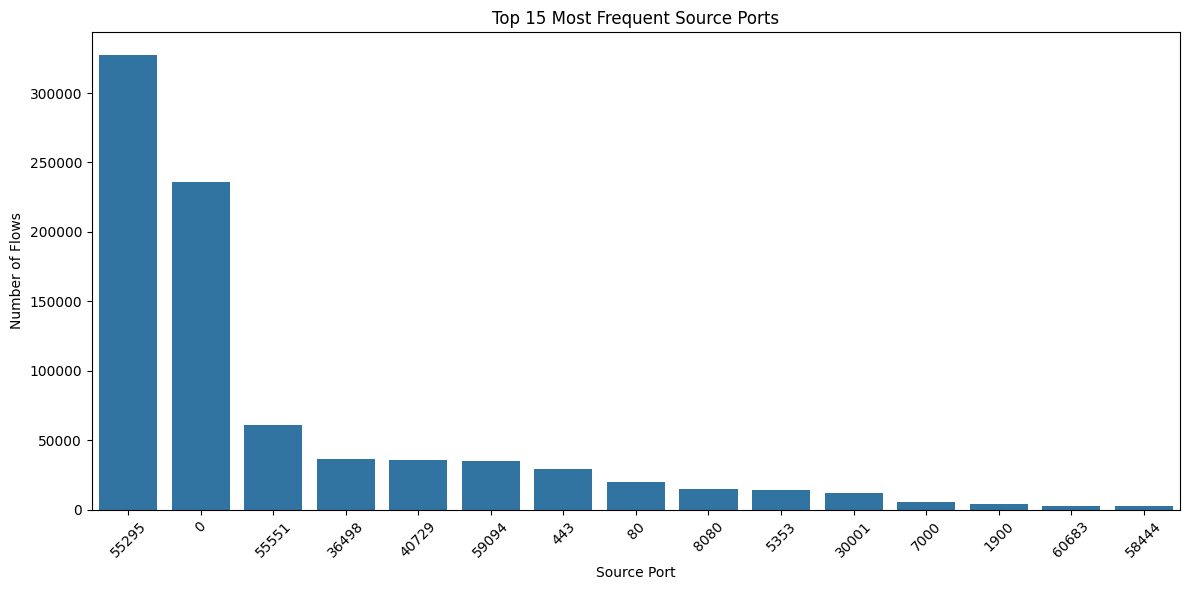

In [76]:
top_src_ports = (
    df["Src Port"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_src_ports.index.astype(str),
    y=top_src_ports.values
)

plt.title("Top 15 Most Frequent Source Ports")
plt.xlabel("Source Port")
plt.ylabel("Number of Flows")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Correlation matrix

In [77]:
# CORRELATION WITH TARGET

target_corr = (
    df.corr(numeric_only=True)["Label"]
    .drop("Label")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

display(target_corr)

RST Flag Count                0.465963
Protocol                     -0.432112
FIN Flag Count               -0.334716
Fwd Packet Length Min        -0.323039
Packet Length Std            -0.287031
Flow Duration                -0.278974
Packet Length Max            -0.260017
Bwd Packet Length Max        -0.231843
SYN Flag Count                0.191945
Flow IAT Min                  0.167810
Dst Port                      0.128050
Bwd Init Win Bytes           -0.121100
FWD Init Win Bytes           -0.115444
Src Port                      0.038904
Total Fwd Packet             -0.038069
Total Bwd packets            -0.036274
ACK Flag Count               -0.034865
Fwd IAT Min                   0.032812
Fwd Header Length            -0.023971
Total Length of Fwd Packet   -0.018542
Bwd Packets/s                 0.009720
Name: Label, dtype: float64

In [78]:
# Select the strongest relationships

top_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top_features_with_label = top_features + ["Label"]

corr_matrix = df[
    top_features_with_label
].corr()

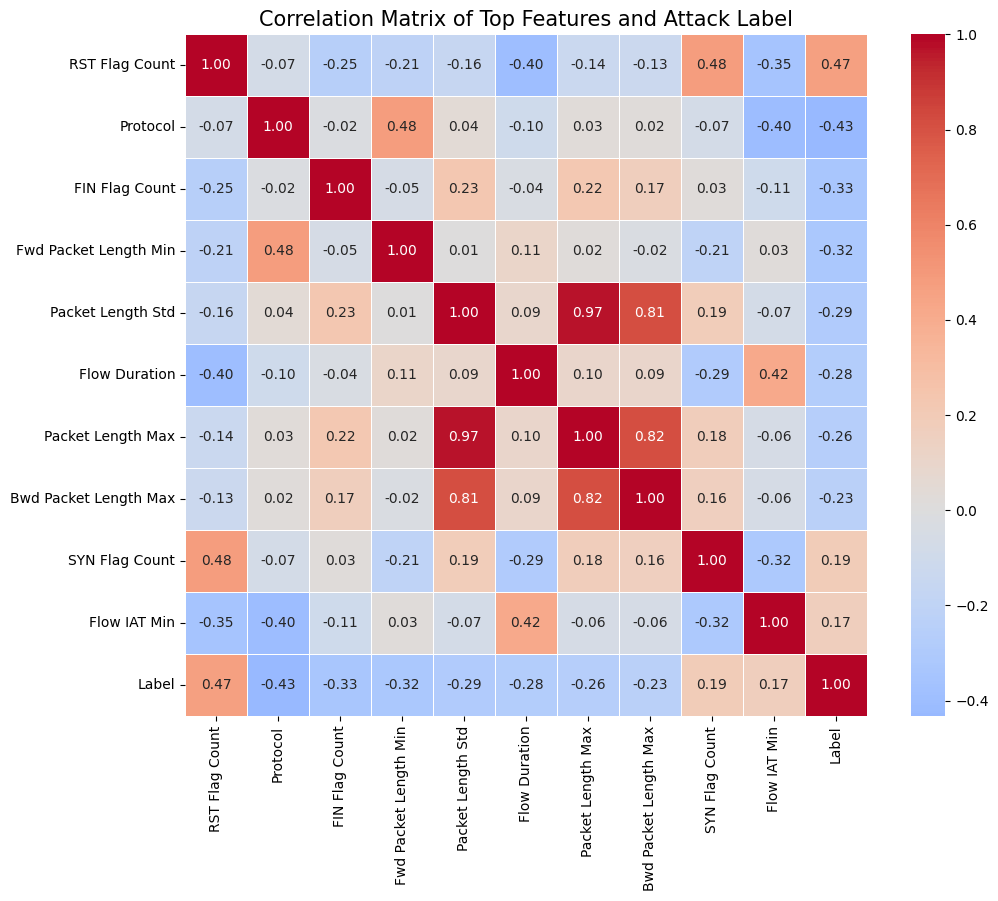

In [79]:
# TOP FEATURE CORRELATION MATRIX

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Top Features and Attack Label",
    fontsize=15
)

plt.tight_layout()
plt.show()

## So the reader can immediately answer:

1. Which features correlate with attack?

2. Which features are strongly related to each other?

3. Are some features redundant?

## The dataset has an important collinearity problem
We found very strong correlations such as:

Total Bwd packets ↔ ACK Flag Count       ≈ 0.975

Packet Length Max ↔ Packet Length Std    ≈ 0.969

Total Fwd Packet ↔ ACK Flag Count        ≈ 0.960

Total Fwd Packet ↔ Fwd Header Length     ≈ 0.960

Fwd Header Length ↔ ACK Flag Count       ≈ 0.930


In [80]:
# HIGHLY CORRELATED FEATURE PAIRS

feature_corr = df.drop(
    columns="Label"
).corr(numeric_only=True)

upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr_pairs["Absolute Correlation"] = (
    high_corr_pairs["Correlation"].abs()
)

high_corr_pairs = (
    high_corr_pairs
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

display(
    high_corr_pairs[
        high_corr_pairs["Absolute Correlation"] >= 0.80
    ]
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
125,Total Bwd packets,ACK Flag Count,0.974653,0.974653
287,Packet Length Max,Packet Length Std,0.969297,0.969297
104,Total Fwd Packet,ACK Flag Count,0.960661,0.960661
95,Total Fwd Packet,Fwd Header Length,0.959670,0.959670
251,Fwd Header Length,ACK Flag Count,0.929744,0.929744
89,Total Fwd Packet,Total Bwd packets,0.900144,0.900144
116,Total Bwd packets,Fwd Header Length,0.855847,0.855847
199,Flow IAT Min,Fwd IAT Min,0.852172,0.852172
181,Bwd Packet Length Max,Packet Length Max,0.816156,0.816156
182,Bwd Packet Length Max,Packet Length Std,0.812956,0.812956


## Visualize the strongest correlations

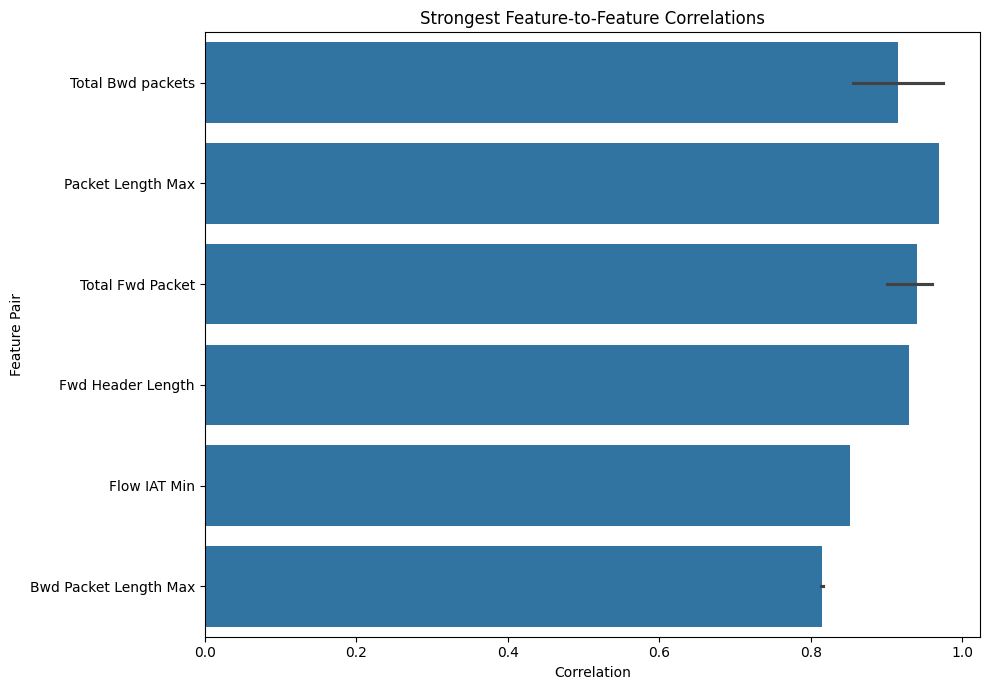

In [81]:

top_pairs = high_corr_pairs.head(10)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_pairs,
    x="Correlation",
    y="Feature 1"
)

plt.title(
    "Strongest Feature-to-Feature Correlations"
)

plt.xlabel("Correlation")
plt.ylabel("Feature Pair")

plt.tight_layout()
plt.show()

### Multicollinearity occurs when multiple features carry very similar information. This can make some models, particularly linear models, unstable or difficult to interpret

## Distribution of the most important features

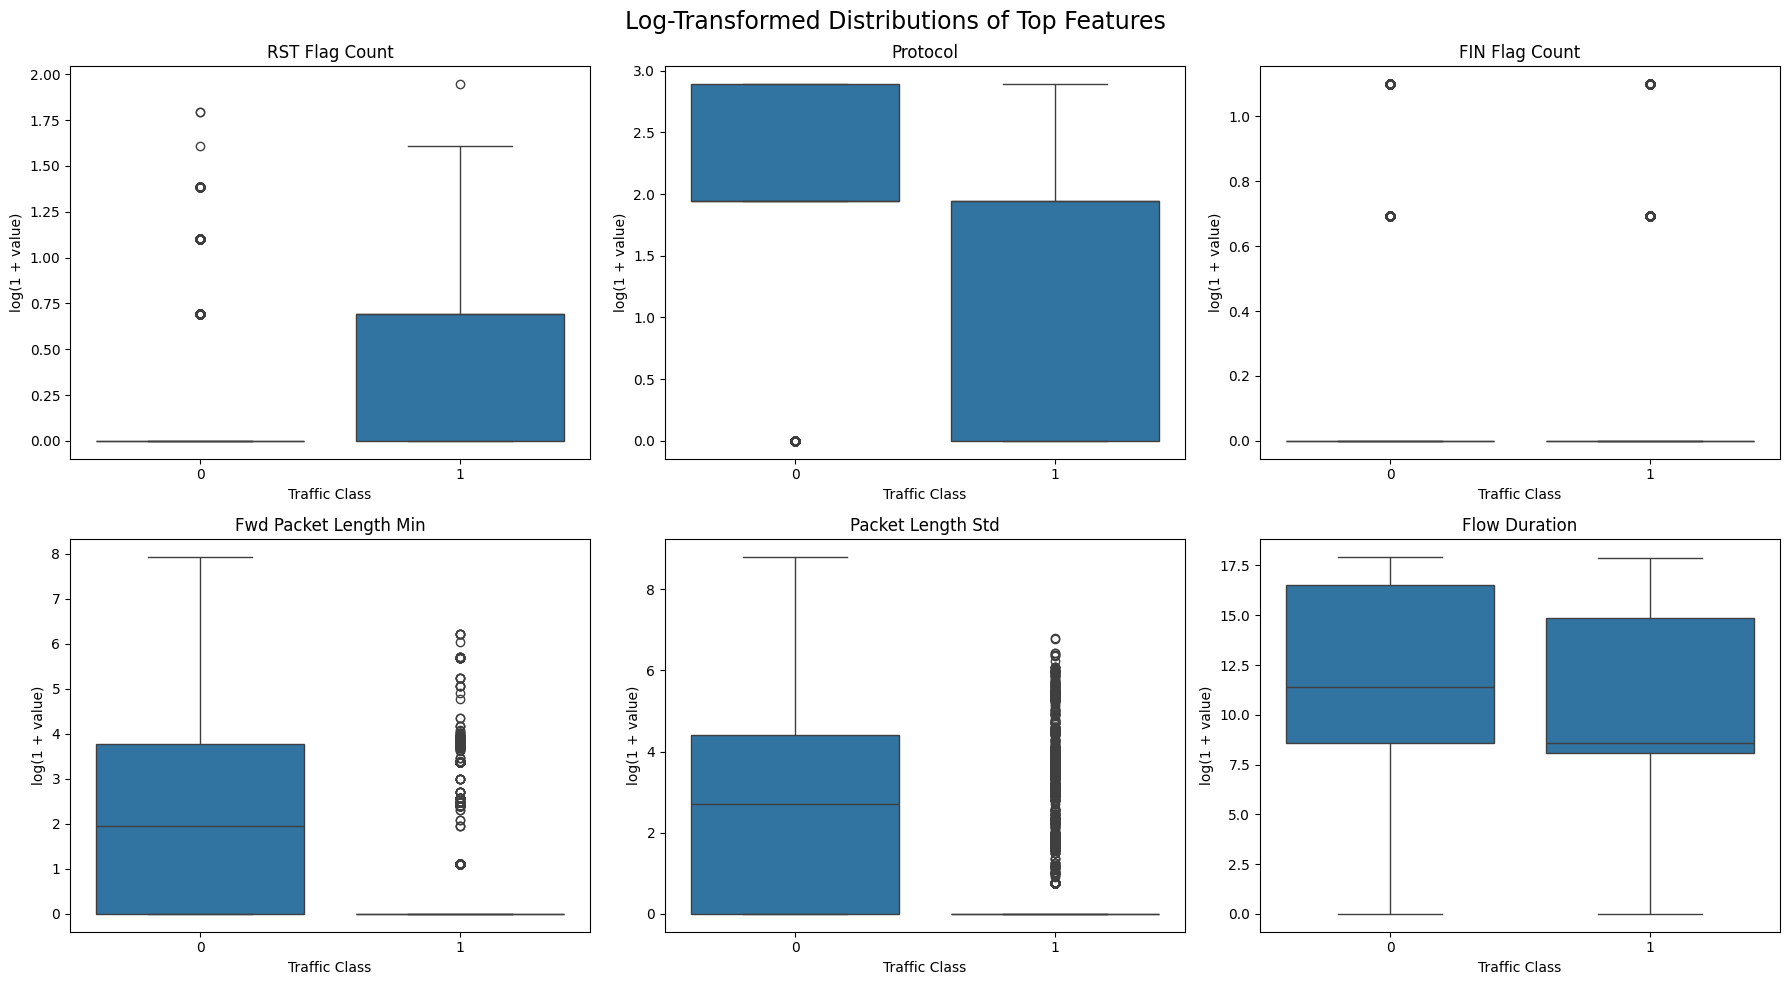

In [82]:
# BOXPLOTS FOR TOP FEATURES

top_6_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, top_6_features):

    temp = eda_sample.copy()

    temp[feature] = np.log1p(
        temp[feature].clip(lower=0)
    )

    sns.boxplot(
        data=temp,
        x="Label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Traffic Class")
    ax.set_ylabel("log(1 + value)")

plt.suptitle(
    "Log-Transformed Distributions of Top Features",
    fontsize=17
)

plt.tight_layout()
plt.show()

## Feature relationship with attack rate

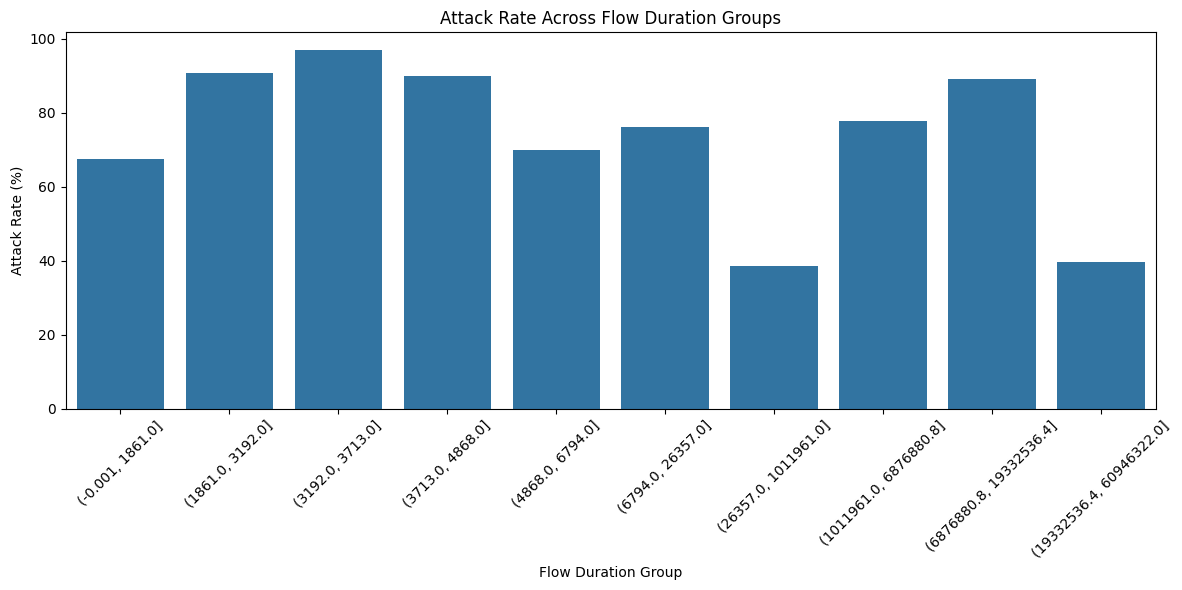

In [83]:
# How does the attack rate change as this feature increases?

# ATTACK RATE VS FLOW DURATION


temp = df[["Flow Duration", "Label"]].copy()

temp["Duration Bin"] = pd.qcut(
    temp["Flow Duration"],
    q=10,
    duplicates="drop"
)

attack_rate = (
    temp.groupby("Duration Bin", observed=True)["Label"]
    .mean() * 100
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=attack_rate.index.astype(str),
    y=attack_rate.values
)

plt.title("Attack Rate Across Flow Duration Groups")
plt.xlabel("Flow Duration Group")
plt.ylabel("Attack Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## OUTLIER DETECTION USING IQR

In [84]:
# Exclude target variable
numeric_features = df.drop(columns=["Label"]).select_dtypes(
    include=np.number
).columns

outlier_results = []

for feature in numeric_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table = outlier_table.sort_values(
    "Outlier %",
    ascending=False
)

display(outlier_table.round(3))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
2,Protocol,6.0,6.000,0.000,6.000,6.000,406129,34.558
14,Packet Length Std,0.0,1.155,1.155,-1.732,2.887,282271,24.019
9,Flow IAT Min,2750.0,90227.000,87477.000,-128465.500,221442.500,279724,23.802
10,Fwd IAT Min,0.0,921891.000,921891.000,-1382836.500,2304727.500,235416,20.032
8,Bwd Packet Length Max,0.0,0.000,0.000,0.000,0.000,227590,19.366
3,Flow Duration,3371.0,3121955.000,3118584.000,-4674505.000,7799831.000,222791,18.957
7,Fwd Packet Length Min,0.0,2.000,2.000,-3.000,5.000,217976,18.548
13,Packet Length Max,0.0,24.000,24.000,-36.000,60.000,215657,18.350
11,Fwd Header Length,8.0,24.000,16.000,-16.000,48.000,188055,16.002
17,Bwd Init Win Bytes,0.0,0.000,0.000,0.000,0.000,182266,15.509


## OUTLIER VISUALIZATION

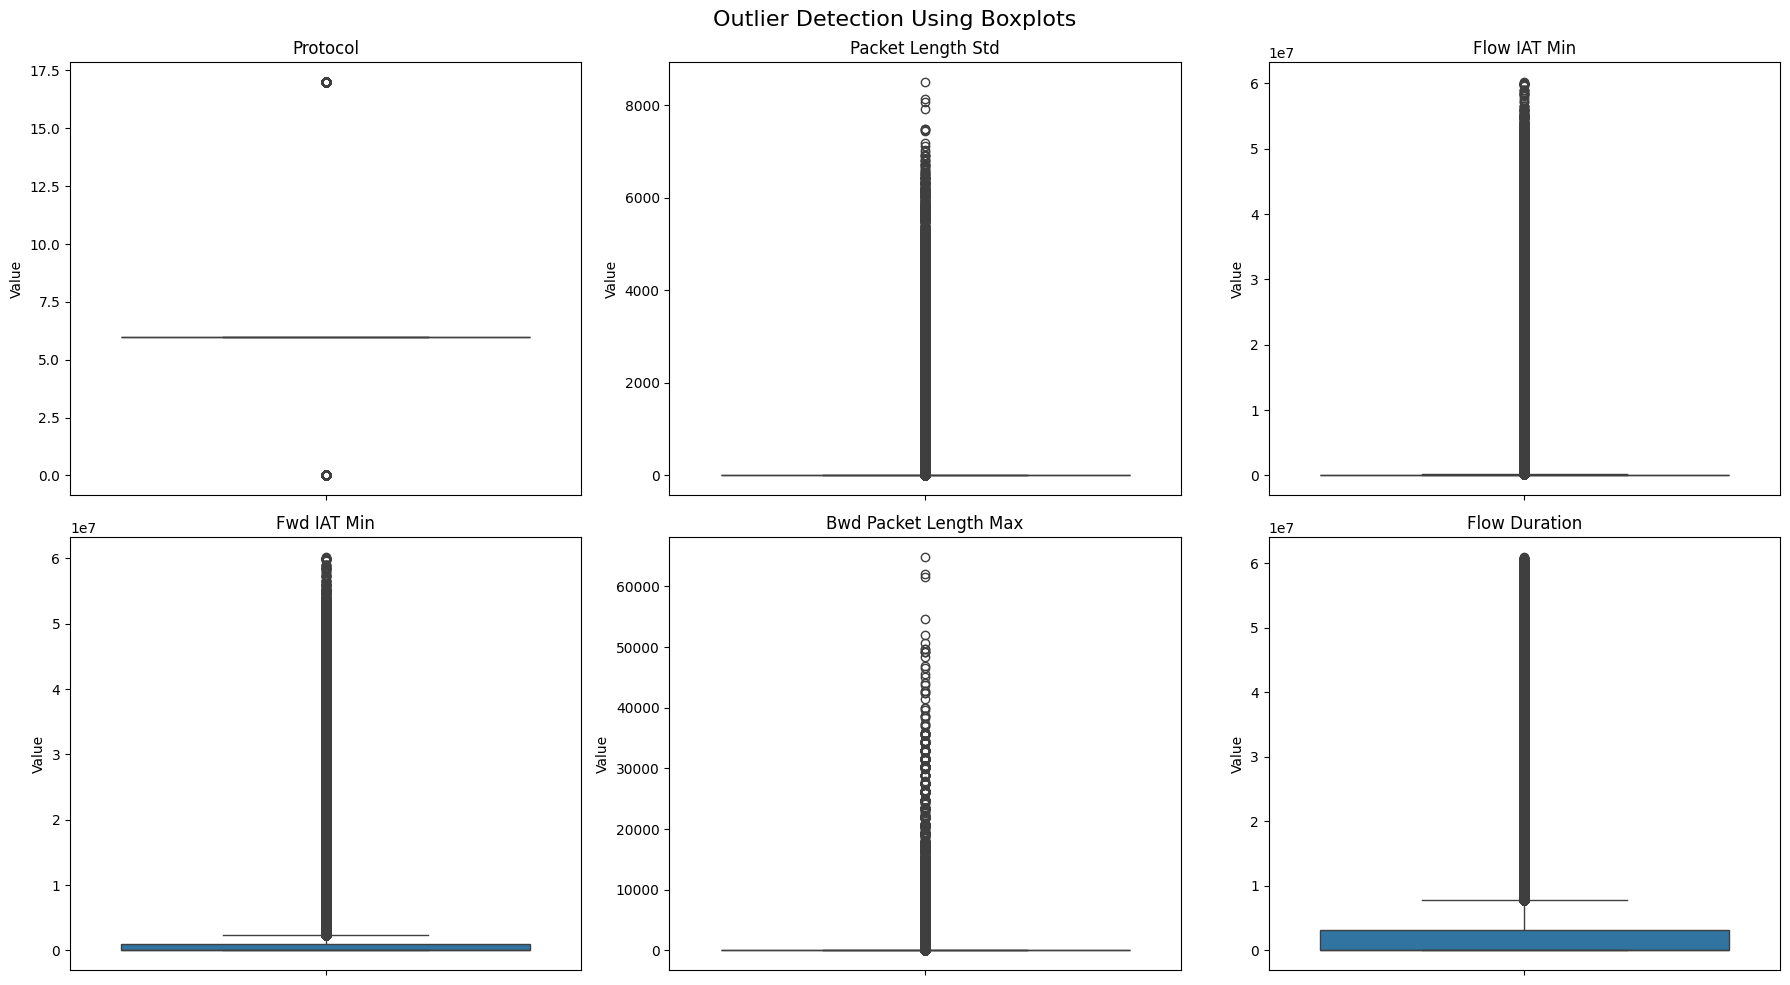

In [85]:
top_outlier_features = (
    outlier_table
    .head(6)["Feature"]
    .tolist()
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, top_outlier_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle(
    "Outlier Detection Using Boxplots",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Modeling

In [86]:
file_path = "IoT_Intrusion_Detection_no_colinearity.csv"

df = pd.read_csv(file_path)

display(df.head())

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Length of Fwd Packet,Fwd Packet Length Min,Flow IAT Min,Bwd Packets/s,Packet Length Std,RST Flag Count,FWD Init Win Bytes,Bwd Init Win Bytes,FIN Flag Count,SYN Flag Count,Label
0,33344,443,6,379933,11,720.0,0.0,1.0,28.952473,669.529745,0,29200,131,1,2,0
1,36754,80,6,205637,3,87.0,0.0,0.0,14.588814,73.493440,0,29200,508,1,2,0
2,36754,80,6,0,2,0.0,0.0,0.0,0.000000,0.000000,0,237,0,1,0,0
3,8080,40426,6,5030379,1,6.0,6.0,0.0,0.397584,3.464102,0,2048,123,1,0,0
4,40054,80,6,72278,3,87.0,0.0,205.0,55.341874,56.782637,0,29200,508,1,2,0


In [87]:
print("Data Shape (Rows, Columns):", df.shape)

print("\nClass Distribution (%):")
print(df['Label'].value_counts(normalize=True) * 100)

Data Shape (Rows, Columns): (1175217, 16)

Class Distribution (%):
Label
1    73.701367
0    26.298633
Name: proportion, dtype: float64


as we observed that the two classes are imbalanced, then we will use stratify split and use the parameter class_weight='balanced' to control this imbalance

In [88]:

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (940173, 15)
X_test shape: (235044, 15)


In [89]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"--- {model_name} Results ---")
    print(f"{'='*40}")
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    
    # Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true, y_pred))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Attack (1)'])
    
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(ax=ax, cmap='Blues', values_format='d') 
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

In [90]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling done!")

Scaling done!


## Start Modeling

---

## LogisticRegression Model

Training Logistic Regression Model...

--- Logistic Regression Results ---
Accuracy: 0.9023

              precision    recall  f1-score   support

           0       0.78      0.88      0.83     61813
           1       0.95      0.91      0.93    173231

    accuracy                           0.90    235044
   macro avg       0.87      0.89      0.88    235044
weighted avg       0.91      0.90      0.90    235044



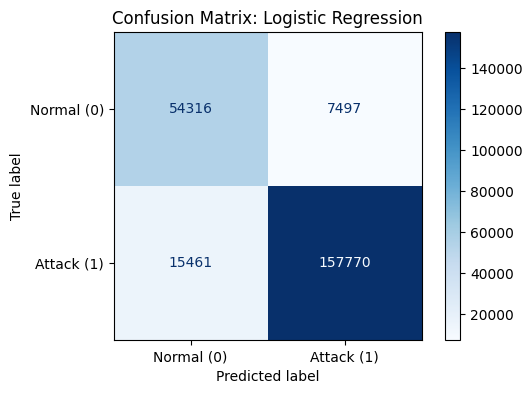

In [91]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

print("Training Logistic Regression Model...")
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

evaluate_model("Logistic Regression", y_test, y_pred_lr)

The performance is acceptable for a baseline with 90% accuracy, but the model misses 15,461 attacks (FN), which is nearly 9% of the 173,231 total actual attacks. This is a critical security risk, meaning we need a more complex model to capture these difficult patterns and reduce false negatives.

---

## RidgeClassifier Model

Training Ridge Classifier...

--- Ridge Classifier Results ---
Accuracy: 0.9073

              precision    recall  f1-score   support

           0       0.78      0.90      0.84     61813
           1       0.96      0.91      0.94    173231

    accuracy                           0.91    235044
   macro avg       0.87      0.90      0.89    235044
weighted avg       0.91      0.91      0.91    235044



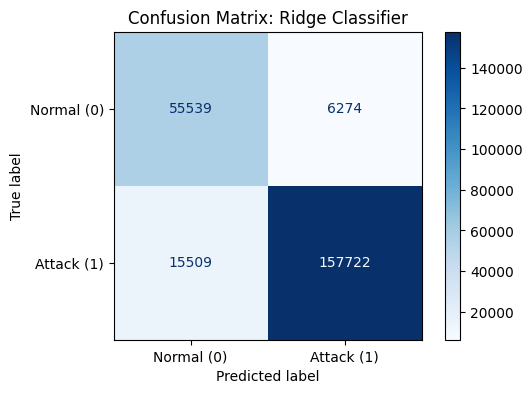

In [92]:
ridge_model = RidgeClassifier(class_weight='balanced', random_state=42)

print("Training Ridge Classifier...")
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

evaluate_model("Ridge Classifier", y_test, y_pred_ridge)

The Ridge Classifier performs like Logistic Regression, because both are linear models they try to seperate data with a straight linear boundary, which is not an effective approach for our specific dataset.

---

## NaiveBayes Model

Training Naive Bayes Model...

--- Naive Bayes Results ---
Accuracy: 0.8218

              precision    recall  f1-score   support

           0       0.87      0.38      0.53     61813
           1       0.82      0.98      0.89    173231

    accuracy                           0.82    235044
   macro avg       0.84      0.68      0.71    235044
weighted avg       0.83      0.82      0.80    235044



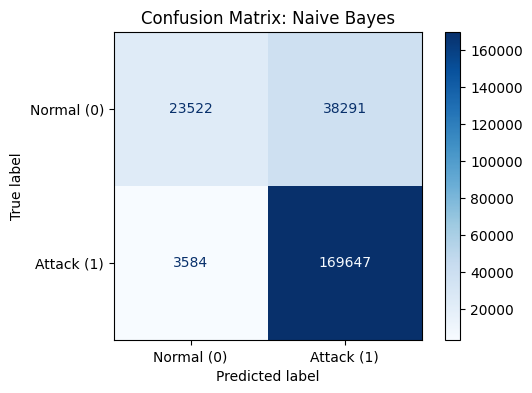

In [93]:
nb_model = GaussianNB()

print("Training Naive Bayes Model...")
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

evaluate_model("Naive Bayes", y_test, y_pred_nb)

The Naive Bayes model dropped in accuracy from 90% to 82%, but it successfully improved the False Negatives. It reduced the percentage of missed attackers from 9% down to almost 2%.

---

## DecisionTree Model

Training Decision Tree Model...

--- Decision Tree Results ---
Accuracy: 0.9957

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     61813
           1       1.00      1.00      1.00    173231

    accuracy                           1.00    235044
   macro avg       0.99      0.99      0.99    235044
weighted avg       1.00      1.00      1.00    235044



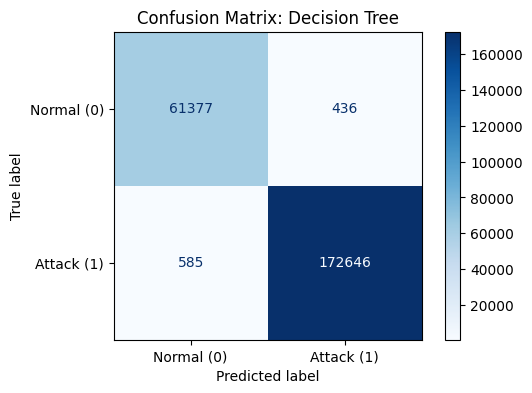

In [94]:
dt_model = DecisionTreeClassifier(
    max_depth=15, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    class_weight='balanced', 
    random_state=42
)

print("Training Decision Tree Model...")
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

evaluate_model("Decision Tree", y_test, y_pred_dt)

The Decision Tree reached 99.57% accuracy, a large jump over the linear models and Naive Bayes, showing that the attack patterns in this dataset need non-linear decision boundaries to be captured well. Both precision and recall for the attack class are close to 1.00, already nearly matching the Random Forest result below.

---

## RandomForest Model

Training Random Forest Model...

--- Random Forest Results ---
Accuracy: 0.9958

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     61813
           1       1.00      1.00      1.00    173231

    accuracy                           1.00    235044
   macro avg       0.99      1.00      0.99    235044
weighted avg       1.00      1.00      1.00    235044



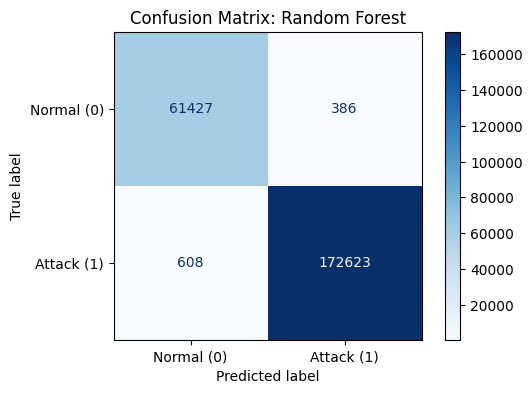

In [95]:
rf_model = RandomForestClassifier(
    n_estimators=100,          
    max_depth=15,              
    min_samples_split=10,      
    min_samples_leaf=5,        
    class_weight='balanced',   
    n_jobs=-1,                 
    random_state=42
)

print("Training Random Forest Model...")
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

evaluate_model("Random Forest", y_test, y_pred_rf)

The model achieved 99.6 percent accuracy on the unseen test data, which proves it is not an overfitting, the model drom the (FN) to be just 569 attacks did not recognize them. the percentage of total actual attacks drops to be less than 1% this means the recall improves, which is our main priority to catch as many threats as possible, while successfully maintaining high precision without any trade off. 

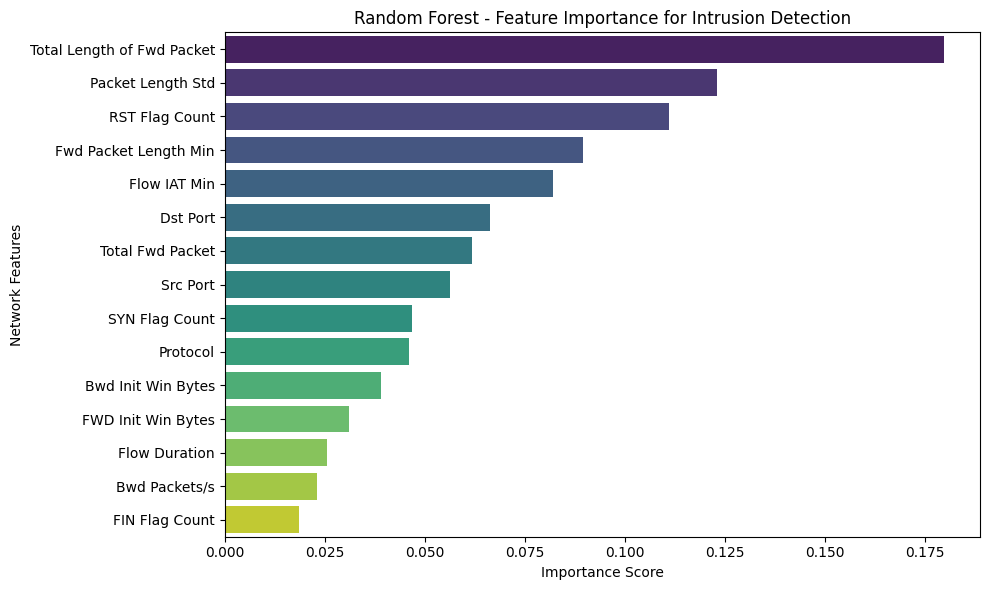

In [96]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest - Feature Importance for Intrusion Detection')
plt.xlabel('Importance Score')
plt.ylabel('Network Features')
plt.tight_layout()
plt.show()

## ROC Curve Comparison

##

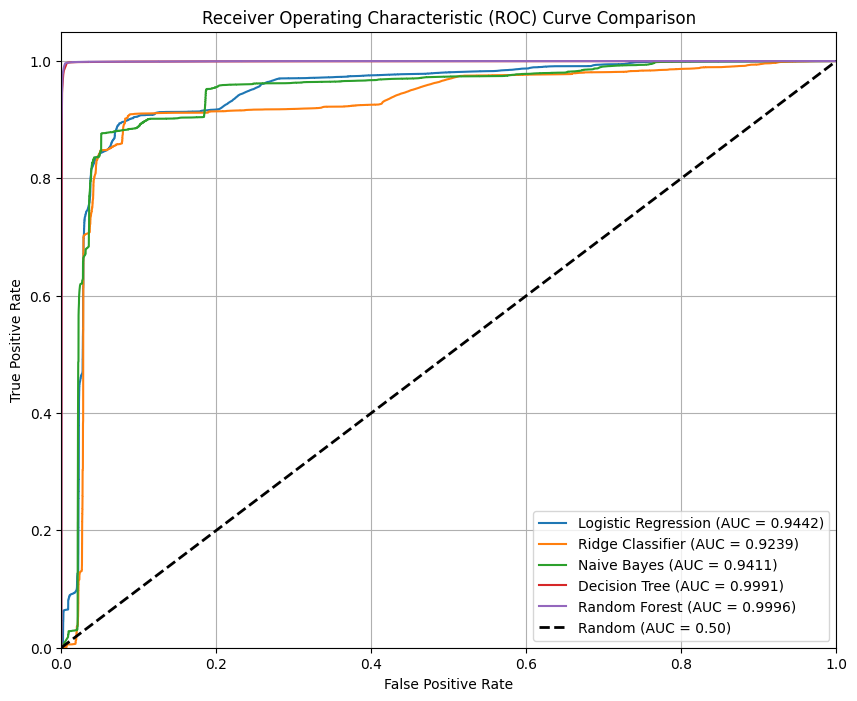

In [97]:
plt.figure(figsize=(10, 8))

def plot_roc(model, X, y_true, name, ax):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X)
    else:
        raise AttributeError(f"Model {name} does not have predict_proba or decision_function.")

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Get the current axes to plot on
ax = plt.gca()

plot_roc(lr_model, X_test_scaled, y_test, 'Logistic Regression', ax)
plot_roc(ridge_model, X_test_scaled, y_test, 'Ridge Classifier', ax)
plot_roc(nb_model, X_test_scaled, y_test, 'Naive Bayes', ax)
plot_roc(dt_model, X_test_scaled, y_test, 'Decision Tree', ax)
plot_roc(rf_model, X_test_scaled, y_test, 'Random Forest', ax)

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve Comparison')
ax.legend(loc='lower right')
plt.grid(True)
plt.show()

## The Most Important Features

*Total Length of Fwd Packet*: reveals attacks because normal IoT devices send tiny data, so sudden massive data spikes expose DDoS or malware activity.

*Packet Length Std*: spots hackers because normal IoT devices always send messages of the exact same size; sudden mixed sizes mean someone is sending abnormal commands.

*RST Flag Count*: spikes when attackers use automated port scanners to knock on closed network ports, causing the devices to constantly reply with reset flags.

## Models Saving

In [100]:
joblib.dump(scaler, "deploy/scaler.joblib")
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Ridge Classifier": ridge_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}
for name, model in models.items():
    filename = f"deploy/models/{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)

print("All models and scaler exported successfully.")

All models and scaler exported successfully.
